In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_wildlife_population.csv")

df.head()

,ID,Binomial,Country,Region,System,Latitude,Longitude,Year,Population,growth_rate
0,28678,Abramis_brama,Estonia,Europe,Freshwater,58.66700,27.48300,1976,1978.95,0.146340
1,6087,Abramis_brama,Netherlands,Europe,Freshwater,52.83333,5.78333,1977,17.33,0.879610
2,28678,Abramis_brama,Estonia,Europe,Freshwater,58.66700,27.48300,1977,1894.74,-0.042553
3,6087,Abramis_brama,Netherlands,Europe,Freshwater,52.83333,5.78333,1978,8.14,-0.530294
4,28678,Abramis_brama,Estonia,Europe,Freshwater,58.66700,27.48300,1978,1894.74,0.000000


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 348678 entries, 0 to 348677
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   ID           348678 non-null  int64  
 1   Binomial     348678 non-null  str    
 2   Country      348678 non-null  str    
 3   Region       348678 non-null  str    
 4   System       348678 non-null  str    
 5   Latitude     348678 non-null  float64
 6   Longitude    348678 non-null  float64
 7   Year         348678 non-null  int64  
 8   Population   348678 non-null  float64
 9   growth_rate  348678 non-null  float64
dtypes: float64(4), int64(2), str(4)
memory usage: 26.6 MB


In [22]:
df.describe()

,ID,Latitude,Longitude,Year,Population,growth_rate
count,3.486780e+05,348678.000000,348678.000000,348678.000000,3.486780e+05,3.486780e+05
mean,4.225063e+04,27.019083,-12.942733,1995.635681,1.337763e+11,3.971509e+06
std,9.351431e+04,36.311766,93.535312,13.729629,1.372028e+13,1.134841e+09
min,1.000000e+00,-78.193822,-180.000000,1950.000000,1.710000e-07,-1.000000e+00
25%,6.061000e+03,-10.013794,-86.000000,1986.000000,1.000000e+00,-6.093879e-01
50%,1.425200e+04,45.290147,-48.000000,1997.000000,1.160000e+01,0.000000e+00
75%,2.328300e+04,54.000000,30.116670,2007.000000,1.650000e+02,1.500000e+00
max,1.000007e+06,81.000000,180.000000,2020.000000,2.460000e+15,5.316659e+11


In [23]:
print("Total records:", len(df))
print("Total species:", df["Binomial"].nunique())
print("Total countries:", df["Country"].nunique())
print("Total regions:", df["Region"].nunique())

Total records: 348678
Total species: 4962
Total countries: 202
Total regions: 8


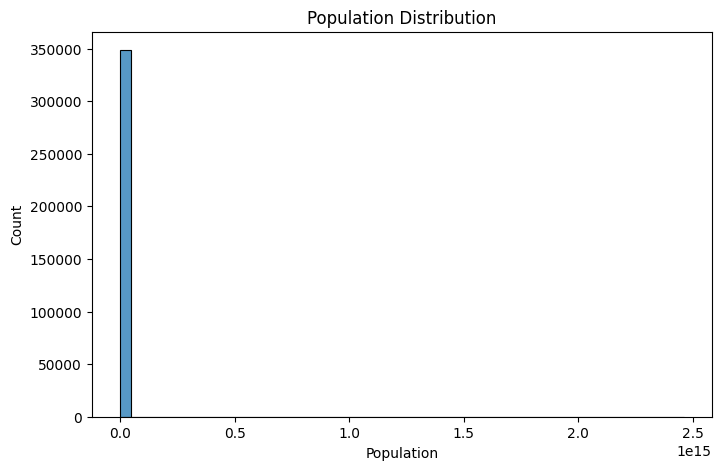

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["Population"], bins=50)
plt.title("Population Distribution")
plt.show()

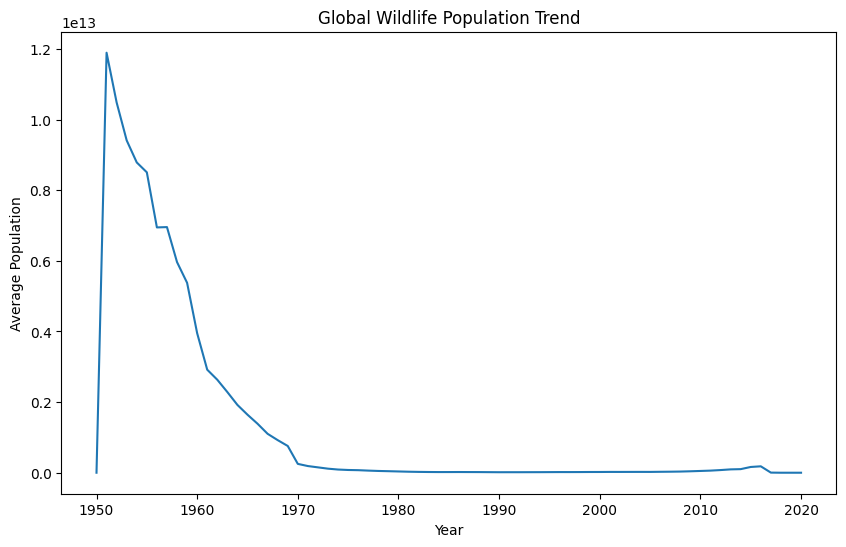

In [25]:
global_trend = df.groupby("Year")["Population"].mean()

plt.figure(figsize=(10,6))
plt.plot(global_trend)
plt.title("Global Wildlife Population Trend")
plt.xlabel("Year")
plt.ylabel("Average Population")
plt.show()

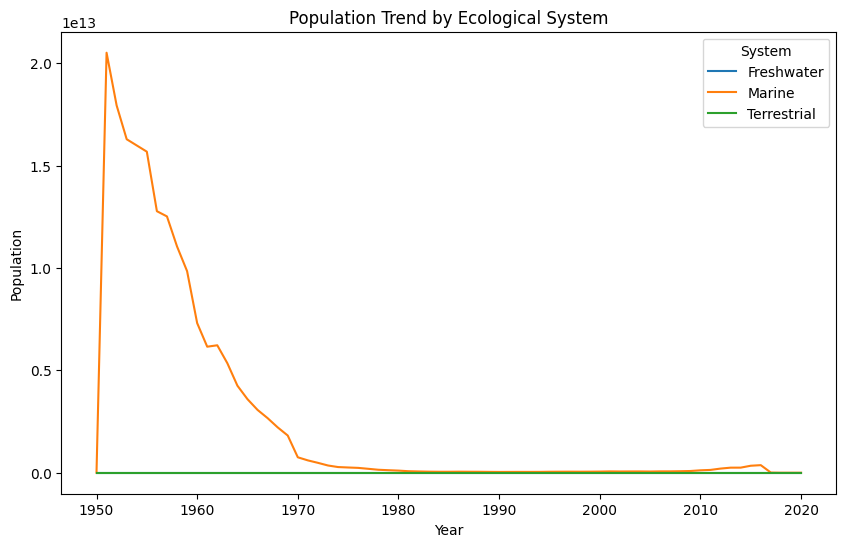

In [26]:
system_trend = df.groupby(["Year","System"])["Population"].mean().reset_index()

plt.figure(figsize=(10,6))

sns.lineplot(
    data=system_trend,
    x="Year",
    y="Population",
    hue="System"
)

plt.title("Population Trend by Ecological System")
plt.show()

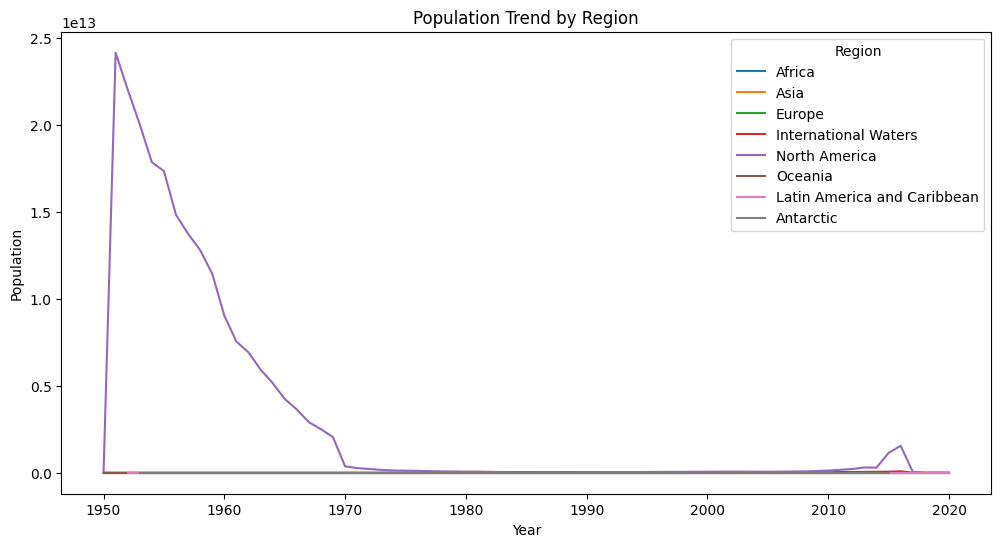

In [27]:
region_trend = df.groupby(["Year","Region"])["Population"].mean().reset_index()

plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_trend,
    x="Year",
    y="Population",
    hue="Region"
)

plt.title("Population Trend by Region")
plt.show()

Binomial
Procapra_picticaudata        -0.999037
Rhagomys_rufescens           -0.998788
Rhipidomys_mastacalis        -0.998600
Eubleekeria_splendens        -0.997840
Polydactylus_virginicus      -0.997704
Atherinella_chagresi         -0.996255
Hylochoerus_meinertzhageni   -0.990000
Phylloscartes_ventralis      -0.983333
Psittacus_erithacus          -0.982947
Colostethus_panamansis       -0.982022
Name: growth_rate, dtype: float64


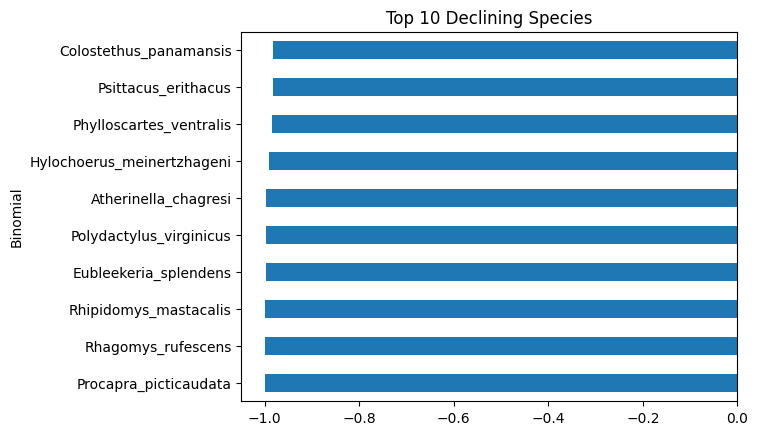

In [28]:
species_decline = df.groupby("Binomial")["growth_rate"].mean()
top_decline = species_decline.sort_values().head(10)
print(top_decline)

top_decline.plot(kind="barh")
plt.title("Top 10 Declining Species")
plt.show()

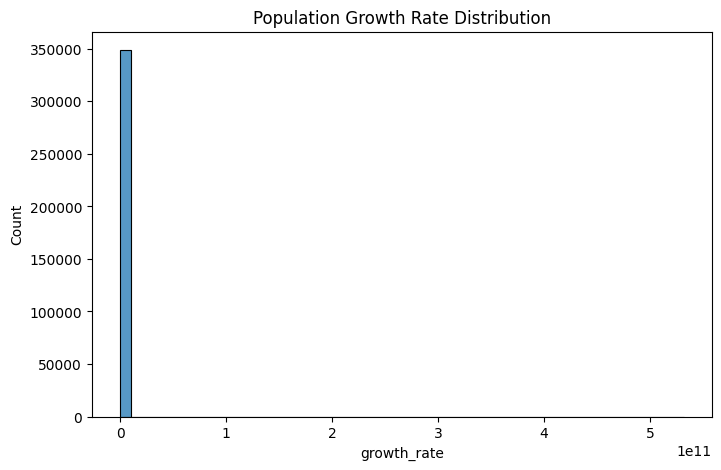

In [29]:
plt.figure(figsize=(8,5))
sns.histplot(df["growth_rate"], bins=50)
plt.title("Population Growth Rate Distribution")
plt.show()

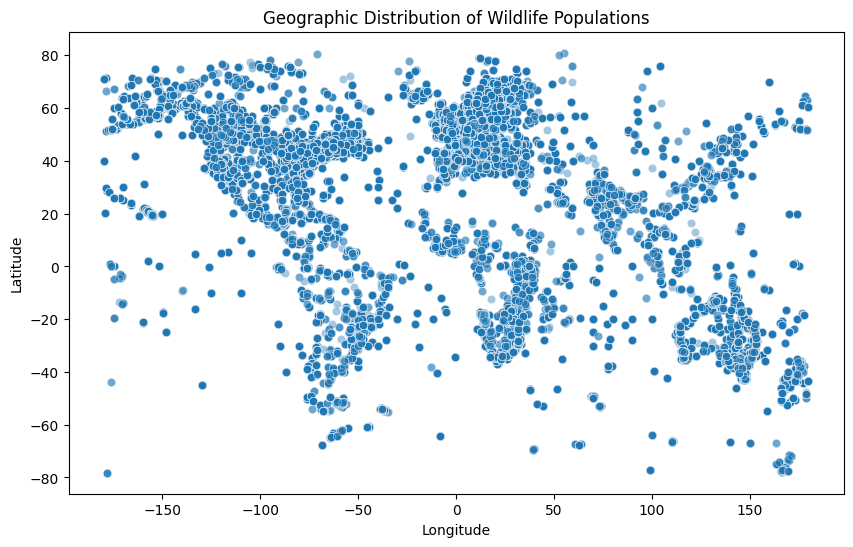

In [30]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    alpha=0.4
)

plt.title("Geographic Distribution of Wildlife Populations")
plt.show()

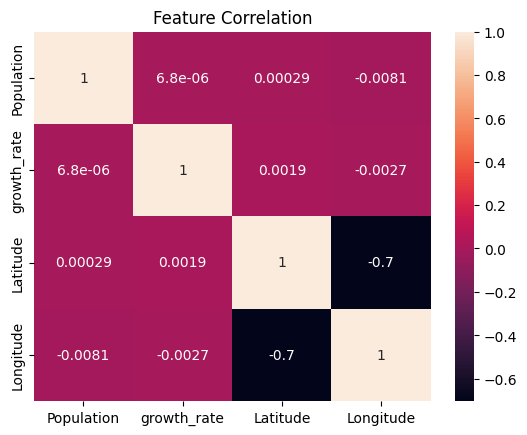

In [31]:
corr = df[[
    "Population",
    "growth_rate",
    "Latitude",
    "Longitude"
]].corr()

sns.heatmap(corr, annot=True)
plt.title("Feature Correlation")
plt.show()

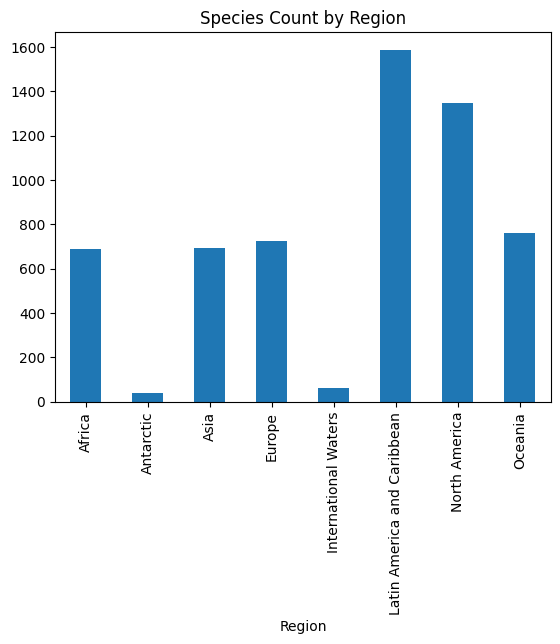

In [32]:
species_region = df.groupby("Region")["Binomial"].nunique()

species_region.plot(kind="bar")
plt.title("Species Count by Region")
plt.show()